# InstanSeg, layer by layer

A visual walk through **`mini_instanseg.py`** — the single-file, NumPy-only
InstanSeg (`brightfield_nuclei`) segmenter in this repo, and a third sibling to
`mini_cellpose_walkthrough.ipynb` and `mini_stardist_walkthrough.ipynb`.

**InstanSeg in three ideas**

1. A U-Net predicts, at every pixel: a 2-D **coordinate** (where the centre of
   *my* object is — a small learned offset added to the pixel's own x, y), a 2-D
   **sigma** (a learned local descriptor), and a scalar **seed** map (how
   centre-like this pixel is).
2. **Seeds** are local maxima of the seed map. Each seed reads off its own
   predicted coordinate.
3. For each seed, a tiny learned **pixel-classifier MLP** looks at every pixel in
   a window and, from *(that pixel's coordinate − the seed's coordinate, and its
   sigma)*, predicts "do you belong to me?". Threshold that → one instance; assign
   each pixel to its highest-probability seed; merge seeds that landed on the same
   object.

A third philosophy: no flow field to integrate (cellpose), no polygon to read off
(stardist) — an object is **grown from its centre by a learned classifier** over a
learned per-pixel embedding. Everything is imported from `mini_instanseg`.

In [31]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mini_instanseg as mi

plt.rcParams["figure.dpi"] = 90
W, meta = mi.load_weights("instanseg_bf_weights.bin", "instanseg_bf_manifest.json")
rf = meta["relu"]
rgb = mi.load_rgb("images/cellpose_image_020.png")           # [3,H,W]
P = mi.DEFAULTS
print(f"weights: {len(meta['tensors'])} tensors   image: {rgb.shape[2]}x{rgb.shape[1]}")

def show_channels(feat, n=8, title=""):
    C = feat.shape[0]; n = min(C, n)
    fig, axs = plt.subplots(1, n, figsize=(1.9*n, 2.3))
    for i in range(n):
        axs[i].imshow(feat[i], cmap="magma"); axs[i].set_title(f"ch{i}", fontsize=8); axs[i].axis("off")
    fig.suptitle(f"{title}   [{C} ch, {feat.shape[1]}x{feat.shape[2]}]", y=1.02); plt.show()

def label_overlay(gray, labels):
    g = (gray - gray.min()) / (np.ptp(gray) + 1e-9)
    out = np.stack([g]*3, -1) * 0.5
    lut = np.random.default_rng(0).random((int(labels.max())+1, 3)); lut[0] = 0
    m = labels > 0; out[m] = 0.35*out[m] + 0.65*lut[labels[m]]
    return out

weights: 88 tensors   image: 881x1001


## 1. Preprocessing

InstanSeg normalizes each channel to its 0.1–99.9 percentile range, then (for the
network to pool cleanly) we reflect-pad to a multiple of 8. Input is 3-channel.

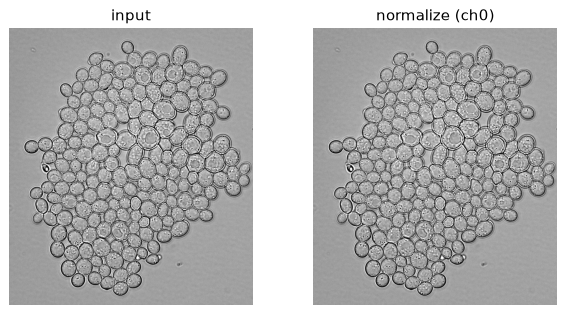

padded: (3, 1008, 888)


In [32]:
norm = mi.percentile_normalize(rgb)
padded, (H, Wd) = mi.pad_to(norm, 8)
x = np.clip(padded, -2, 3)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(np.moveaxis(rgb, 0, 2).astype(np.uint8)); ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(norm[0], cmap="gray"); ax[1].set_title("normalize (ch0)"); ax[1].axis("off")
plt.show()
print("padded:", x.shape)

## 2. The U-Net (encoder → decoder)

An InstanSeg_UNet: 4 residual encoder blocks (32→64→128→256, pooling 3×) and 3
decoder blocks that upsample and merge skips. We run it stage by stage and look at
the feature maps. (BatchNorm was folded into each conv by `export_instanseg.py`.)

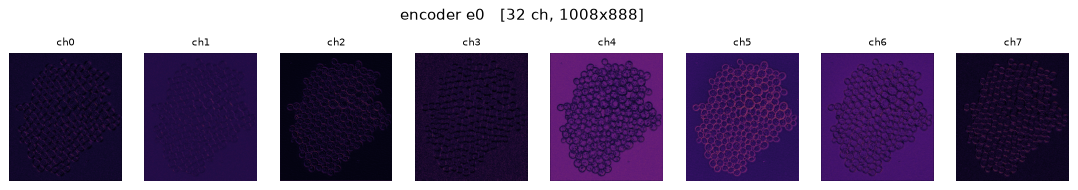

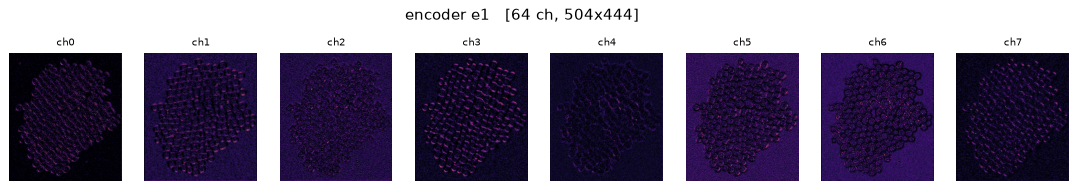

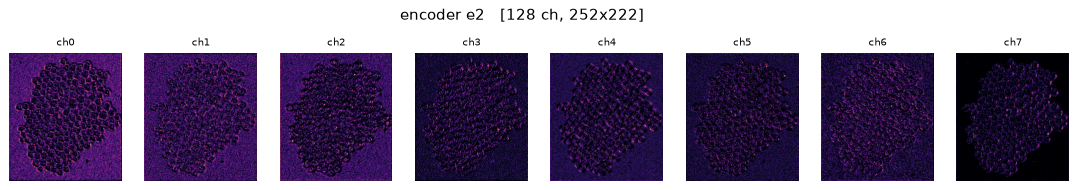

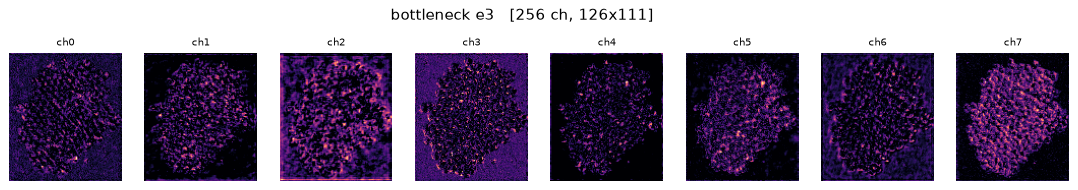

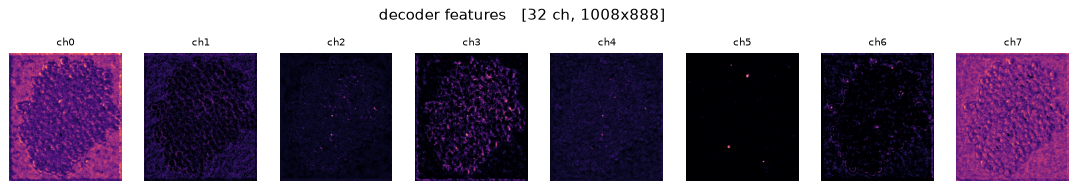

In [33]:
e0 = mi.enc_block(W, rf, 0, x, pool=False)
e1 = mi.enc_block(W, rf, 1, e0, pool=True)
e2 = mi.enc_block(W, rf, 2, e1, pool=True)
e3 = mi.enc_block(W, rf, 3, e2, pool=True)
d = mi.dec_block(W, rf, 0, e3, e2)
d = mi.dec_block(W, rf, 1, d, e1)
d = mi.dec_block(W, rf, 2, d, e0)     # [32,H,W] shared decoder features
show_channels(e0, 8, "encoder e0")
show_channels(e1, 8, "encoder e1")
show_channels(e2, 8, "encoder e2")
show_channels(e3, 8, "bottleneck e3")
show_channels(d, 8, "decoder features")

## 3. The five output channels

Three 1×1 heads read the decoder features into **2 coordinate fields**, **2 sigma
channels**, and **1 seed map**. The coordinate fields are the interesting part:
`field = (sigmoid(out) − 0.5)·8 + (pixel's own x,y)`, i.e. each pixel points at the
centre of its object.

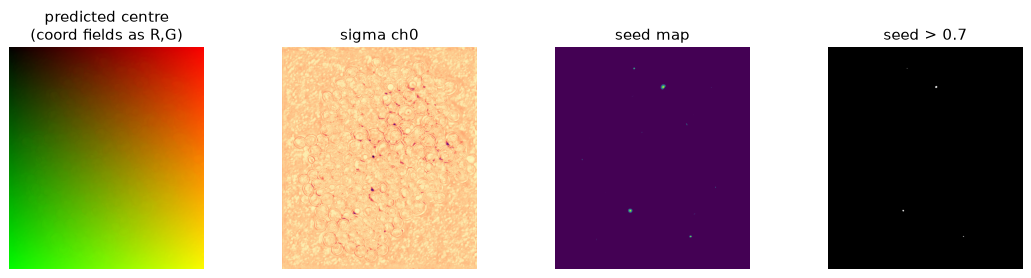

In [34]:
out = mi.fcn_forward(W, rf, x)[:, :H, :Wd]        # [5,H,W]
fields = (mi.sigmoid(out[0:2]) - 0.5) * 8 + mi.coordinate_map(H, Wd)
sigma = out[2:4]
seed_map = out[4] / 15.0 + 0.5

fig, axs = plt.subplots(1, 4, figsize=(15, 3.2))
# colour each pixel by its PREDICTED centre coordinate -> pixels of one nucleus share a colour
fc = fields.copy()
r = (fc[0] - fc[0].min()) / (np.ptp(fc[0]) + 1e-9)
g = (fc[1] - fc[1].min()) / (np.ptp(fc[1]) + 1e-9)
axs[0].imshow(np.stack([r, g, np.zeros_like(r)], -1)); axs[0].set_title("predicted centre\n(coord fields as R,G)"); axs[0].axis("off")
axs[1].imshow(sigma[0], cmap="magma"); axs[1].set_title("sigma ch0"); axs[1].axis("off")
axs[2].imshow(seed_map, cmap="viridis"); axs[2].set_title("seed map"); axs[2].axis("off")
axs[3].imshow(seed_map > P["seed_threshold"], cmap="gray"); axs[3].set_title(f"seed > {P['seed_threshold']}"); axs[3].axis("off")
plt.show()

## 4. Seeds

Local maxima of the seed map (peaks at least `peak_distance` apart, above
`seed_threshold`) are the object centres. Each seed will grow into one instance.

4 seeds


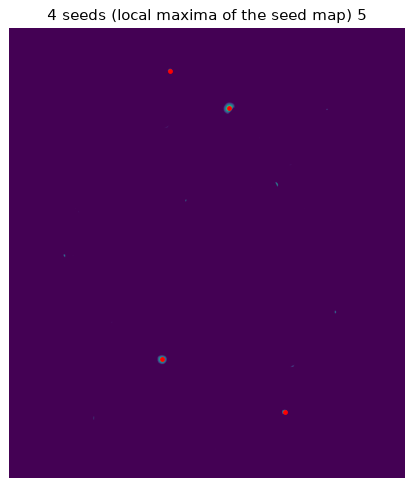

In [35]:
centroids = mi.peak_local_max(seed_map, P["peak_distance"], P["seed_threshold"])
print(f"{len(centroids)} seeds")
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.imshow(seed_map, cmap="viridis")
ax.scatter(centroids[:, 1], centroids[:, 0], s=8, c="red")
ax.set_title(f"{len(centroids)} seeds (local maxima of the seed map) {P["peak_distance"]}"); ax.axis("off")
plt.show()

## 5. One seed's learned classifier

For a single seed, the pixel-classifier MLP runs over a 64×64 window: for each
pixel it takes *(pixel coordinate − seed coordinate, sigma)* → 4 numbers → a
probability of belonging to this seed. Thresholding + a flood-fill from the seed
gives that one instance's mask.

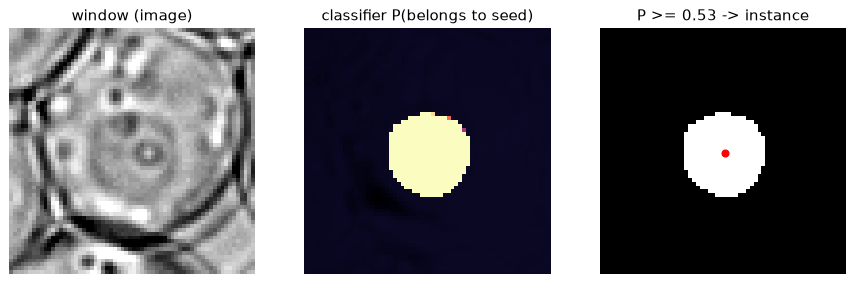

In [36]:
# pick a seed near the middle of the image for a clear crop
mid = np.array([H//2, Wd//2])
i = int(np.argmin(((centroids - mid) ** 2).sum(1)))
cy, cx = centroids[i]
c = fields[:, cy, cx]
sz = min(P["window_size"], H, Wd) * 2; half = sz // 2
y0 = int(np.clip(cy, half, H - half)) - half
x0 = int(np.clip(cx, half, Wd - half)) - half
ys = np.clip(np.arange(y0, y0 + sz), 0, H - 1); xs = np.clip(np.arange(x0, x0 + sz), 0, Wd - 1)
gy, gx = np.meshgrid(ys, xs, indexing="ij")
feat = np.stack([fields[0, gy, gx] - c[0], fields[1, gy, gx] - c[1], sigma[0, gy, gx], sigma[1, gy, gx]], -1).reshape(-1, 4)
prob = mi.sigmoid(mi.pixel_classifier(W, feat)).reshape(sz, sz)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(norm[0, y0:y0+sz, x0:x0+sz], cmap="gray"); ax[0].set_title("window (image)"); ax[0].axis("off")
ax[1].imshow(prob, cmap="magma"); ax[1].set_title("classifier P(belongs to seed)"); ax[1].axis("off")
ax[2].imshow(prob >= P["mask_threshold"], cmap="gray")
ax[2].scatter([cx-x0], [cy-y0], c="red", s=30); ax[2].set_title(f"P >= {P['mask_threshold']} -> instance"); ax[2].axis("off")
plt.show()

## 6. Final labels

Do that for every seed, assign each pixel to its highest-probability seed, merge
seeds that landed on the same object (mask IoU > `overlap_threshold`), drop tiny
ones — the segmentation. `mini_instanseg.segment` does all of it in one call, in
NumPy, no PyTorch.

==> 4 nuclei


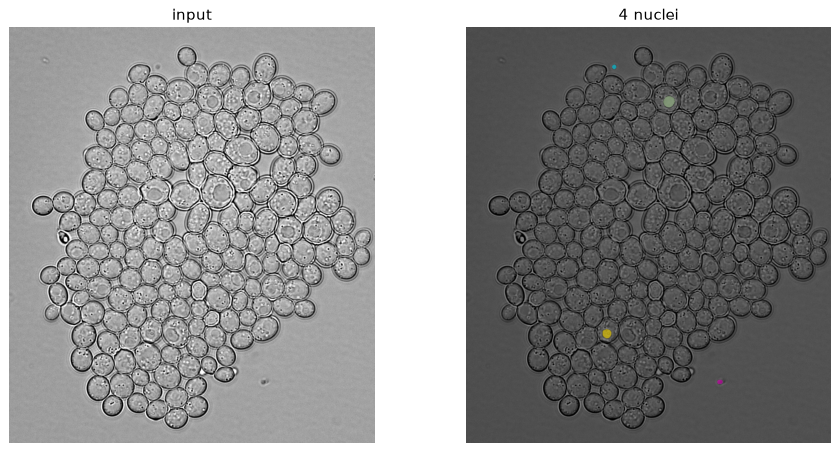

In [37]:
labels = mi.segment(W, rf, rgb, P, verbose=False)
print(f"==> {int(labels.max())} nuclei")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(norm[0], cmap="gray"); ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(label_overlay(norm[0], labels)); ax[1].set_title(f"{int(labels.max())} nuclei"); ax[1].axis("off")
plt.show()

## That's the whole pipeline

**normalize → U-Net → (coord fields, sigma, seed) → seed peaks → per-seed learned
classifier over the coordinate embedding → assign + merge.** Against InstanSeg's
own output this port matches at **AP@0.5 = 1.000 / 0.996 / 1.000** on the three
samples (`python mini_instanseg.py <img> --validate`).

Three siblings, three philosophies for the same task: cellpose *integrates a flow
field* to centres, stardist *reads a polygon* straight off distance channels, and
instanseg *grows each object from its centre* with a learned classifier over a
learned embedding.